In [3]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-slwx33gk
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-slwx33gk
  Resolved https://www.github.com/mouseland/cellpose.git to commit 71e7e887216c36d06f01ca3e9958a06949980d90
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 82.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 79.2 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.2.dev16+g71e7e8872-py3-none-any.whl size=214482 sha256=79d95b46485227eb23c099b56e60da92835ab821065131b57ee10c02616be4bc
  Stored in directory: /tmp/pip-ephem-wheel-cache-_7yq3r9c/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


In [16]:
!nvidia-smi

Fri Apr 24 14:33:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   47C    P0             28W /   72W |    8674MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# USEFULL TO UPLOAD DATA TO OWNCLLOUD, BUT NOT NEEDED FOR THE TOOL IF DATA IS ALREADY ON THE SERVER

# import owncloud, getpass, cellpose

# # Config
# url, user = 'url', 'user'
# oc_session = owncloud.Client(url)
# oc_session.login(user, getpass.getpass(f"PW {user}: "))
# oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

# import tool
# oc = tool.Owncloud(oc_session)

# print("Tool chargé et prêt.")

Tool chargé et prêt.


In [ ]:
# oc.upload_data()

In [ ]:
# oc.upload_scripts()

In [2]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tool
import pandas as pd


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [ ]:

oc.upload_models()

In [ ]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits_SG = json.load(f)

ids_test_SG  = splits_SG['test']

with open('./data/dataset_splits_3D_annotations_actuelles.json', 'r') as f:
    splits = json.load(f)

ids_test  = splits['test']
ids_train = splits['train']
ids_val   = splits['val']   

ids_tot = ids_test + ids_train + ids_val

print(f"Splits chargés : train({len(ids_train)})", f"val({len(ids_val)})")

Splits chargés : train(46) val(4)


In [4]:
df_annotations = pd.read_csv('./data/Nuclei.csv', sep=';')
df_meta = pd.read_csv('./data/Correspondance Stacks3D et base annotée.csv', sep=';')

In [5]:
ids_candidats = list(set(ids_test_SG) & set(ids_tot))
print(f"Nombre de candidats : {len(ids_candidats)}")

# B. On filtre le DataFrame : On garde les candidats QUI ONT 'oui'
df_filtre = df_meta[
    (df_meta['correspondance'] == 'oui') & 
    (df_meta['ImageFilename'].str[:3].isin(ids_candidats))
]

liste_finale_ids = df_filtre['ImageFilename'].str[:3].tolist()

print(f"Nombre d'images finales : {len(liste_finale_ids)}")

Nombre de candidats : 11
Nombre d'images finales : 9


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from contextlib import redirect_stdout
from cellpose import models, io

# --- 1. CONFIGURATION DU BENCHMARK ---
bench_configs = [
    {
        "label": "raw_2channel_cellpose4",
        "target": "Z",              
        "annotation_target": "Cell",
        "load_method": "channel",
        "mode": "raw",
        "params": {"channels": [1, 2], "flow_threshold": 0.5, "cellprob_threshold": 0.0},
        "model_path": "./models/cyto4_40_raw.pth" 
    },
    {
        "label": "Nuclei_cellpose4",
        "target": "Z",                
        "annotation_target": "Nuc",    
        "load_method": "data",
        "params": {"channels": [0, 0], "flow_threshold": 0.4, "cellprob_threshold": -0.5},
        "model_path": "./models/cellpose4_nuclei.pth"
    }
]

ev = tool.Stats()

base_output = os.path.abspath("./results/benchmark_z_granuleuse_test")
os.makedirs(base_output, exist_ok=True)

donnees_pour_graphes = {}

# --- 2. BOUCLE PRINCIPALE ---
for config in bench_configs:
    print(f"\nLancement de l'évaluation : {config['label']}...")
    
    model_root = os.path.join(base_output, config['label'])
    output_dir_masks = os.path.join(model_root, "masks")
    output_dir_viz = os.path.join(model_root, "viz")
    
    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)
    
    model = models.CellposeModel(gpu=True, pretrained_model=config['model_path'])
    
    masks_pred_list = []
    Y_true_list = []

    # Pré-chargement des images multi-canaux (uniquement si nécessaire)
    if config['load_method'] == "channel":
        # Ajout des arguments obligatoires: df_meta et step=0 (pour cibler la granuleuse)
        X_val_multi = visualizer.load_channel_z_relative(
            liste_finale_ids, 
            df_meta=df_filtre, 
            step=0, 
            mode=config['mode']
        )

    for idx, img_id in enumerate(liste_finale_ids):

        row = df_filtre[df_filtre['ImageFilename'].str.startswith(img_id)]
        z_granuleuse = int(row['granuleuse'].values[0])
        
        if config['load_method'] == "channel":
            img_input = X_val_multi[idx]
            img_visu = img_input[0]
        else:
          
            img_brute = visualizer.load_data(img_id, target='Z', z_level=z_granuleuse)
            if img_brute is None:
                continue
                
            img_input = cv2.normalize(img_brute, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            img_visu = img_input

        # --- C. Inférence ---
        masks, _, _ = model.eval(img_input, **config['params'])
        
        masks_pred_list.append(masks)
        
        # --- D. Sauvegarde ---
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_{config['annotation_target']}_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # --- F. Visualisation ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        ax1, ax2 = axes.flatten()
        
        ax1.imshow(img_visu, cmap='gray')
        ax1.set_title("A. Image Entrée (Z=granuleuse)", fontweight='bold') 
        ax1.axis('off')

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target=config['target'], annotation = False, z_level=z_granuleuse)
        ax2.set_title("B. Superposition ( rouge cellpose)")
        ax2.axis('off')
        
        titre_rapport = (f"Rapport Image : {img_id}")
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)

# --- 4. EXPORT ---
print("\nExportation de l'intégralité du dossier benchmark...")
try:
    chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/benchmark_stack_granuleuse"
    oc.download_path(base_output, chemin_export_global)
    print(f"Export réussi vers : {chemin_export_global}")

except Exception as e:
    print(f"Erreur lors de l'export global : {e}")


Lancement de l'évaluation : raw_2channel_cellpose4...



Lancement de l'évaluation : Nuclei_cellpose4...



Exportation de l'intégralité du dossier benchmark...
Dossier benchmark_z_granuleuse_test envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_stack_granuleuse.zip
Export réussi vers : /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_stack_granuleuse


2026-04-24 13:21:41,837 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-24 13:21:41,838 [INFO] 
cellpose version: 	4.1.2.dev16+g71e7e8872 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128

ÉTAPE 1/11 : Apprentissage du plan Z=1 à partir de Z=0
Génération des pseudo-labels pour Z=1...
2026-04-24 13:21:42,144 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:21:42,145 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:21:44,363 [INFO] >>>> loading model ./models/cellpose4_nuclei.pth
2026-04-24 13:21:45,307 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:22:11,557 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.75it/s]
2026-04-24 13:22:11,558 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:22:13,842 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.75it/s]
Sauvegarde des ma

100%|██████████| 46/46 [00:01<00:00, 32.54it/s]

2026-04-24 13:23:09,937 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 33.25it/s]

2026-04-24 13:23:10,062 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 691.05it/s]

2026-04-24 13:23:10,131 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 13:23:10,132 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:23:10,462 [INFO] >>> n_epochs=6, n_train=45, n_test=4
2026-04-24 13:23:10,462 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:23:10,464 [INFO] >>> saving model to models/Nuclei_cellpose4_z1
2026-04-24 13:23:28,123 [INFO] 0, train_loss=0.1050, test_loss=0.0907, LR=0.000000, time 17.66s
2026-04-24 13:24:54,286 [INFO] 5, train_loss=0.0776, test_loss=0.0506, LR=0.000006, time 103.82s
2026-04-24 13:24:54,287 [INFO] saving network parameters to models/Nuclei_cellpose4_z1
2026-04-24 13:25:04,374 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=1 sauvegardé : models/Nuclei_cellpose4_z1


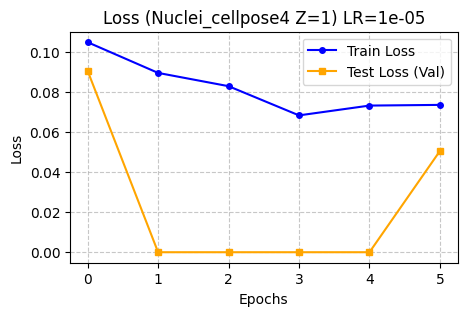


ÉTAPE 2/11 : Apprentissage du plan Z=2 à partir de Z=1
Génération des pseudo-labels pour Z=2...
2026-04-24 13:25:04,829 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:25:04,830 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:25:06,834 [INFO] >>>> loading model models/Nuclei_cellpose4_z1
2026-04-24 13:25:07,615 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:25:34,202 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.73it/s]
2026-04-24 13:25:34,203 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:25:36,503 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.74it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:26:31,632 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:26:31,643 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 31.70it/s]

2026-04-24 13:26:33,121 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 33.17it/s]

2026-04-24 13:26:33,248 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 691.82it/s]

2026-04-24 13:26:33,317 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 13:26:33,318 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:26:33,646 [INFO] >>> n_epochs=6, n_train=45, n_test=4
2026-04-24 13:26:33,647 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:26:33,649 [INFO] >>> saving model to models/Nuclei_cellpose4_z2
2026-04-24 13:26:51,142 [INFO] 0, train_loss=0.1004, test_loss=0.0709, LR=0.000000, time 17.49s
2026-04-24 13:28:17,466 [INFO] 5, train_loss=0.0882, test_loss=0.0625, LR=0.000006, time 103.82s
2026-04-24 13:28:17,467 [INFO] saving network parameters to models/Nuclei_cellpose4_z2
2026-04-24 13:28:28,222 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=2 sauvegardé : models/Nuclei_cellpose4_z2


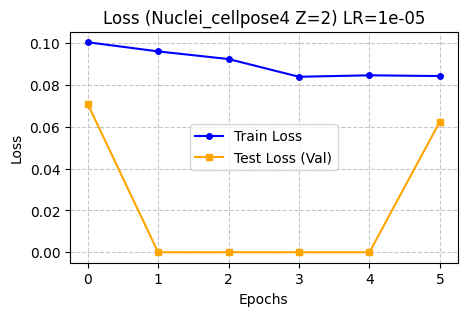


ÉTAPE 3/11 : Apprentissage du plan Z=3 à partir de Z=2
Génération des pseudo-labels pour Z=3...
2026-04-24 13:28:28,677 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:28:28,677 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:28:30,663 [INFO] >>>> loading model models/Nuclei_cellpose4_z2
2026-04-24 13:28:31,336 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:28:58,178 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.71it/s]
2026-04-24 13:28:58,179 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:29:00,507 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.72it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:29:56,127 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:29:56,138 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 31.49it/s]

2026-04-24 13:29:57,625 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 31.94it/s]

2026-04-24 13:29:57,756 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 666.03it/s]

2026-04-24 13:29:57,827 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:29:58,162 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:29:58,163 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:29:58,165 [INFO] >>> saving model to models/Nuclei_cellpose4_z3
2026-04-24 13:30:16,030 [INFO] 0, train_loss=0.1000, test_loss=0.0944, LR=0.000000, time 17.87s
2026-04-24 13:31:44,305 [INFO] 5, train_loss=0.0953, test_loss=0.0916, LR=0.000006, time 106.14s
2026-04-24 13:31:44,306 [INFO] saving network parameters to models/Nuclei_cellpose4_z3
2026-04-24 13:31:55,379 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=3 sauvegardé : models/Nuclei_cellpose4_z3


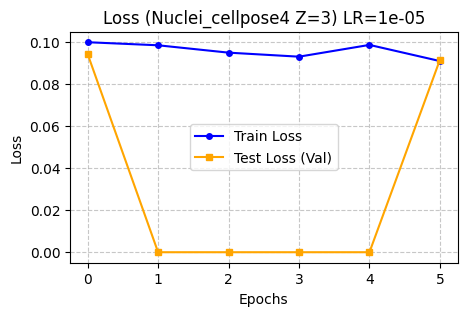


ÉTAPE 4/11 : Apprentissage du plan Z=4 à partir de Z=3
Génération des pseudo-labels pour Z=4...
2026-04-24 13:31:55,869 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:31:55,870 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:31:57,942 [INFO] >>>> loading model models/Nuclei_cellpose4_z3
2026-04-24 13:31:58,606 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:32:25,495 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.71it/s]
2026-04-24 13:32:25,496 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:32:27,830 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.71it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:33:23,167 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:33:23,177 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 32.83it/s]

2026-04-24 13:33:24,604 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 34.06it/s]

2026-04-24 13:33:24,727 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 709.88it/s]

2026-04-24 13:33:24,796 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 13:33:24,797 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:33:25,122 [INFO] >>> n_epochs=6, n_train=45, n_test=4
2026-04-24 13:33:25,123 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:33:25,125 [INFO] >>> saving model to models/Nuclei_cellpose4_z4
2026-04-24 13:33:42,653 [INFO] 0, train_loss=0.1073, test_loss=0.0888, LR=0.000000, time 17.53s
2026-04-24 13:35:09,121 [INFO] 5, train_loss=0.1085, test_loss=0.0789, LR=0.000006, time 104.00s
2026-04-24 13:35:09,121 [INFO] saving network parameters to models/Nuclei_cellpose4_z4
2026-04-24 13:35:20,743 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=4 sauvegardé : models/Nuclei_cellpose4_z4


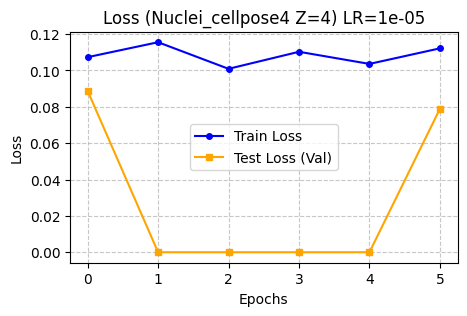


ÉTAPE 5/11 : Apprentissage du plan Z=5 à partir de Z=4
Génération des pseudo-labels pour Z=5...
2026-04-24 13:35:21,204 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:35:21,205 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:35:23,191 [INFO] >>>> loading model models/Nuclei_cellpose4_z4
2026-04-24 13:35:23,861 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:35:50,716 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.71it/s]
2026-04-24 13:35:50,717 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:35:53,043 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.72it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:36:48,429 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:36:48,443 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 33.97it/s]

2026-04-24 13:36:49,823 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 34.96it/s]

2026-04-24 13:36:49,943 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 696.15it/s]

2026-04-24 13:36:50,012 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 13:36:50,013 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:36:50,335 [INFO] >>> n_epochs=6, n_train=45, n_test=4
2026-04-24 13:36:50,336 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:36:50,338 [INFO] >>> saving model to models/Nuclei_cellpose4_z5
2026-04-24 13:37:07,814 [INFO] 0, train_loss=0.1222, test_loss=0.1198, LR=0.000000, time 17.48s
2026-04-24 13:38:34,117 [INFO] 5, train_loss=0.1151, test_loss=0.1113, LR=0.000006, time 103.78s
2026-04-24 13:38:34,118 [INFO] saving network parameters to models/Nuclei_cellpose4_z5
2026-04-24 13:38:44,747 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=5 sauvegardé : models/Nuclei_cellpose4_z5


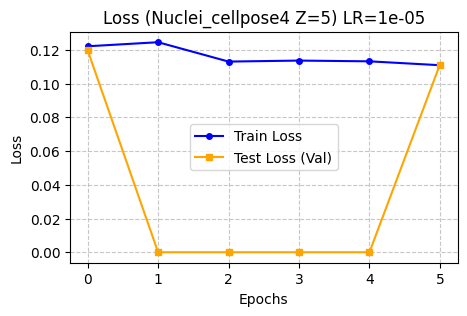


ÉTAPE 6/11 : Apprentissage du plan Z=6 à partir de Z=5
Génération des pseudo-labels pour Z=6...
2026-04-24 13:38:45,214 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:38:45,215 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:38:47,214 [INFO] >>>> loading model models/Nuclei_cellpose4_z5
2026-04-24 13:38:47,882 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:39:14,500 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.73it/s]
2026-04-24 13:39:14,501 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:39:16,841 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.71it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:40:11,959 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:40:11,970 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 34.99it/s]

2026-04-24 13:40:13,311 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 34.06it/s]

2026-04-24 13:40:13,434 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 744.83it/s]

2026-04-24 13:40:13,504 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 13:40:13,505 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:40:13,823 [INFO] >>> n_epochs=6, n_train=45, n_test=4
2026-04-24 13:40:13,824 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:40:13,825 [INFO] >>> saving model to models/Nuclei_cellpose4_z6
2026-04-24 13:40:31,302 [INFO] 0, train_loss=0.1214, test_loss=0.1107, LR=0.000000, time 17.48s
2026-04-24 13:41:57,658 [INFO] 5, train_loss=0.1001, test_loss=0.1160, LR=0.000006, time 103.83s
2026-04-24 13:41:57,659 [INFO] saving network parameters to models/Nuclei_cellpose4_z6
2026-04-24 13:42:08,945 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=6 sauvegardé : models/Nuclei_cellpose4_z6


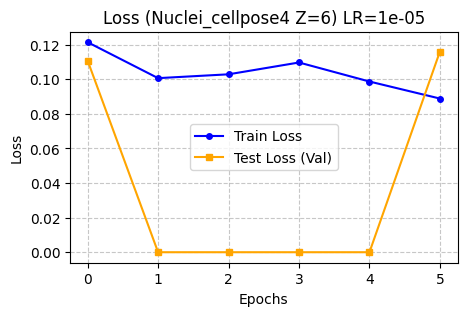


ÉTAPE 7/11 : Apprentissage du plan Z=7 à partir de Z=6
Génération des pseudo-labels pour Z=7...
2026-04-24 13:42:09,435 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:42:09,436 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:42:11,441 [INFO] >>>> loading model models/Nuclei_cellpose4_z6
2026-04-24 13:42:12,113 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:42:38,522 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.74it/s]
2026-04-24 13:42:38,523 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:42:40,826 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.74it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:43:35,462 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:43:35,472 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 36.93it/s]

2026-04-24 13:43:36,744 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 34.88it/s]

2026-04-24 13:43:36,864 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 716.21it/s]

2026-04-24 13:43:36,934 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:43:37,256 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:43:37,257 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:43:37,259 [INFO] >>> saving model to models/Nuclei_cellpose4_z7
2026-04-24 13:43:55,169 [INFO] 0, train_loss=0.0994, test_loss=0.0901, LR=0.000000, time 17.91s
2026-04-24 13:45:23,553 [INFO] 5, train_loss=0.0870, test_loss=0.0830, LR=0.000006, time 106.29s
2026-04-24 13:45:23,554 [INFO] saving network parameters to models/Nuclei_cellpose4_z7
2026-04-24 13:45:34,376 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=7 sauvegardé : models/Nuclei_cellpose4_z7


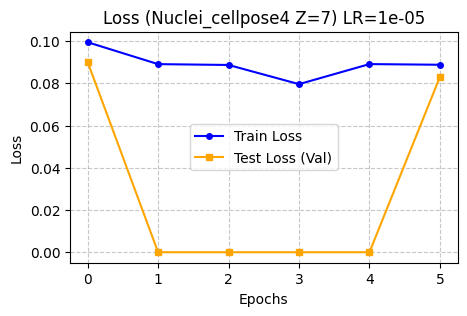


ÉTAPE 8/11 : Apprentissage du plan Z=8 à partir de Z=7
Génération des pseudo-labels pour Z=8...
2026-04-24 13:45:34,848 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:45:34,848 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:45:36,873 [INFO] >>>> loading model models/Nuclei_cellpose4_z7
2026-04-24 13:45:37,971 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:46:04,427 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.74it/s]
2026-04-24 13:46:04,428 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:46:06,698 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.76it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:47:00,814 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:47:00,824 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 37.85it/s]

2026-04-24 13:47:02,066 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 39.50it/s]

2026-04-24 13:47:02,172 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 763.16it/s]

2026-04-24 13:47:02,240 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:47:02,560 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:47:02,561 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:47:02,563 [INFO] >>> saving model to models/Nuclei_cellpose4_z8
2026-04-24 13:47:20,424 [INFO] 0, train_loss=0.0913, test_loss=0.0571, LR=0.000000, time 17.86s
2026-04-24 13:48:48,716 [INFO] 5, train_loss=0.0900, test_loss=0.0611, LR=0.000006, time 106.15s
2026-04-24 13:48:48,717 [INFO] saving network parameters to models/Nuclei_cellpose4_z8
2026-04-24 13:48:59,745 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=8 sauvegardé : models/Nuclei_cellpose4_z8


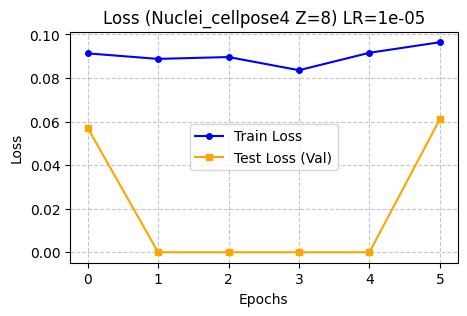


ÉTAPE 9/11 : Apprentissage du plan Z=9 à partir de Z=8
Génération des pseudo-labels pour Z=9...
2026-04-24 13:49:00,203 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:49:00,204 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:49:02,178 [INFO] >>>> loading model models/Nuclei_cellpose4_z8
2026-04-24 13:49:02,848 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:49:29,188 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.75it/s]
2026-04-24 13:49:29,189 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:49:31,474 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.75it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:50:26,038 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:50:26,049 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 37.53it/s]

2026-04-24 13:50:27,300 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 38.15it/s]

2026-04-24 13:50:27,410 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 735.91it/s]

2026-04-24 13:50:27,481 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:50:27,806 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:50:27,807 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:50:27,809 [INFO] >>> saving model to models/Nuclei_cellpose4_z9
2026-04-24 13:50:45,694 [INFO] 0, train_loss=0.0855, test_loss=0.0659, LR=0.000000, time 17.88s
2026-04-24 13:52:14,002 [INFO] 5, train_loss=0.0825, test_loss=0.0638, LR=0.000006, time 106.19s
2026-04-24 13:52:14,003 [INFO] saving network parameters to models/Nuclei_cellpose4_z9
2026-04-24 13:52:25,048 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=9 sauvegardé : models/Nuclei_cellpose4_z9


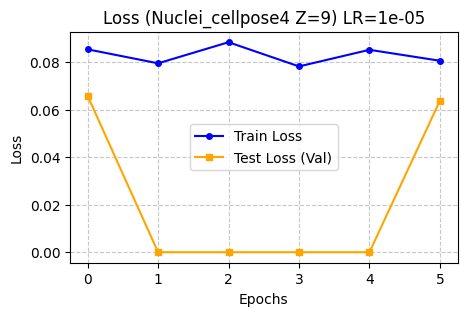


ÉTAPE 10/11 : Apprentissage du plan Z=10 à partir de Z=9
Génération des pseudo-labels pour Z=10...
2026-04-24 13:52:25,509 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:52:25,510 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:52:27,489 [INFO] >>>> loading model models/Nuclei_cellpose4_z9
2026-04-24 13:52:28,158 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:52:54,324 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.76it/s]
2026-04-24 13:52:54,325 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:52:56,590 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.77it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:53:50,974 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:53:50,984 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 39.35it/s]

2026-04-24 13:53:52,178 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 40.85it/s]

2026-04-24 13:53:52,281 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 758.40it/s]

2026-04-24 13:53:52,350 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:53:52,677 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:53:52,678 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:53:52,680 [INFO] >>> saving model to models/Nuclei_cellpose4_z10
2026-04-24 13:54:10,542 [INFO] 0, train_loss=0.0612, test_loss=0.0642, LR=0.000000, time 17.86s
2026-04-24 13:55:38,744 [INFO] 5, train_loss=0.0656, test_loss=0.0613, LR=0.000006, time 106.07s
2026-04-24 13:55:38,745 [INFO] saving network parameters to models/Nuclei_cellpose4_z10
2026-04-24 13:55:51,874 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=10 sauvegardé : models/Nuclei_cellpose4_z10


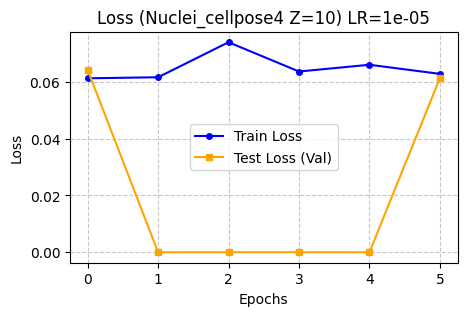


ÉTAPE 11/11 : Apprentissage du plan Z=11 à partir de Z=10
Génération des pseudo-labels pour Z=11...
2026-04-24 13:55:52,338 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 13:55:52,338 [INFO] >>>> using GPU (CUDA)
2026-04-24 13:55:54,317 [INFO] >>>> loading model models/Nuclei_cellpose4_z10
2026-04-24 13:55:54,981 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:56:21,061 [INFO] 100%|##########| 46/46 [00:26<00:00,  1.76it/s]
2026-04-24 13:56:21,062 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 13:56:23,332 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.76it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 13:57:17,525 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 13:57:17,536 [INFO] computing flows for labels


100%|██████████| 46/46 [00:01<00:00, 39.46it/s]

2026-04-24 13:57:18,727 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 41.68it/s]

2026-04-24 13:57:18,828 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 732.85it/s]

2026-04-24 13:57:18,898 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 13:57:19,220 [INFO] >>> n_epochs=6, n_train=46, n_test=4
2026-04-24 13:57:19,221 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 13:57:19,223 [INFO] >>> saving model to models/Nuclei_cellpose4_z11
2026-04-24 13:57:37,108 [INFO] 0, train_loss=0.0566, test_loss=0.0535, LR=0.000000, time 17.89s
2026-04-24 13:59:05,388 [INFO] 5, train_loss=0.0580, test_loss=0.0570, LR=0.000006, time 106.17s
2026-04-24 13:59:05,389 [INFO] saving network parameters to models/Nuclei_cellpose4_z11
2026-04-24 13:59:12,084 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=11 sauvegardé : models/Nuclei_cellpose4_z11


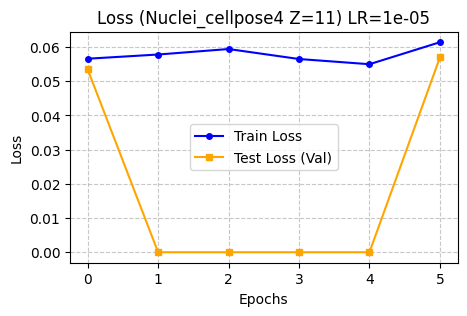


Entraînement séquentiel 3D terminé avec succès.


HTTPResponseError: HTTP error: 504

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io

label = "Nuclei_cellpose4"
target = "Nuc"                                    
initial_model_path = "./models/cellpose4_nuclei.pth" 
total_steps = 12

# Paramètres d'inférence et d'entraînement
eval_params = {
    "channels": [0, 0],
    "diameter": None,
    "flow_threshold": 0.4,
    "cellprob_threshold": -0.5
}

train_params = {
    "n_epochs": 6, # <-- Recommandé de baisser pour le tracker (ex: 5 à 10)
    "learning_rate": 1e-5,
    "weight_decay": 0.0001,
    "save_path": '.'
}

io.logger_setup()
current_model_path = initial_model_path

base_output = os.path.abspath("./results/sequential_training")
os.makedirs(base_output, exist_ok=True)

for i in range(total_steps - 1):
    z_current = i
    z_next = i + 1

    print(f"\n{'='*6}")
    print(f"ÉTAPE {z_next}/{total_steps-1} : Apprentissage du plan Z={z_next} à partir de Z={z_current}")
    print(f"{'='*6}")

    # --- 1. Création des dossiers (ATTENTION: z_next doit être défini avant) ---
    model_root = os.path.join(base_output, f"step_{z_next}")
    output_dir_masks = os.path.join(model_root, "masks")
    output_dir_viz = os.path.join(model_root, "viz")
    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    # --- 2. Chargement des images cibles (Z+1) ---
    X_train_next = visualizer.load_set_z_relative(ids_train, df_meta=df_meta, step=z_next, total_steps=total_steps)
    X_val_next = visualizer.load_set_z_relative(ids_val, df_meta=df_meta, step=z_next, total_steps=total_steps)

    # --- 3. Évaluation Vectorisée (GPU à 100%) ---
    print(f"Génération des pseudo-labels pour Z={z_next}...")
    model_eval = models.CellposeModel(gpu=True, pretrained_model=current_model_path)

    # Cellpose traite toute la liste X d'un seul coup et recrache une liste Y
    Y_train_pseudo, _, _= model_eval.eval(X_train_next, **eval_params)
    Y_val_pseudo, _, _ = model_eval.eval(X_val_next, **eval_params)

    # --- 4. Boucle de Sauvegarde et Plotting (Train & Val) ---
    print("Sauvegarde des masques et génération des graphiques...")
    
    # On fusionne Train et Val pour traiter toutes les sauvegardes dans la même boucle logique
    all_ids = ids_train + ids_val
    all_X = X_train_next + X_val_next
    all_Y = Y_train_pseudo + Y_val_pseudo

    # zip() permet de lire l'ID, l'image et le masque en même temps !
    for img_id, img_array, mask_pred in zip(all_ids, all_X, all_Y):
        
        # Sauvegarde du masque
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_{target}_pred.bmp")
        cv2.imwrite(save_path_mask, mask_pred.astype(np.uint16)) 

        # Visualisation directe (sans repasser par load_data)
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        ax1, ax2 = axes.flatten()
        
        ax1.imshow(img_array, cmap='gray')
        ax1.set_title(f"A. Image Entrée (Z-relatif={z_next})")
        ax1.axis('off')

        # Si votre plot_overlay prend un array NumPy en argument (mask_pred) :
        visualizer.plot_overlay(i=img_id, mask_pred=mask_pred, ax=ax2, show=False, annotation=False, prediction=True, image= img_array)
        ax2.set_title(f"B. Prédiction Cellpose - {target}")
        
        titre_rapport = f"Pseudo-label : {img_id} ({label})"
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        fig.subplots_adjust(top=0.90)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    
    # --- 5. Fine-Tuning du Modèle ---
    print(f"Affinage du modèle sur les pseudo-labels...")
    model_name = f"{label}_z{z_next}"

    new_model_path, t_loss, v_loss = train.train_seg(
        model_eval.net,
        train_data=X_train_next,
        train_labels=Y_train_pseudo,
        test_data=X_val_next,
        test_labels=Y_val_pseudo,
        model_name=model_name,
        **train_params 
    )

    print(f"Modèle Z={z_next} sauvegardé : {new_model_path}")

    # --- 6. Affichage de la Loss ---
    title = f"Loss ({label} Z={z_next}) LR={train_params['learning_rate']}"
    visualizer.plot_loss(t_loss, v_loss, title=title, show=True)

    # Mise à jour du poids pour le palier suivant
    current_model_path = new_model_path

print("\nEntraînement séquentiel 3D terminé avec succès.")
chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_stack"
oc.download_path(base_output, chemin_export_global)
# oc.oc.put_file(
#     '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_nuclei_stack.pth',
#     current_model_path, timeout=600                                  
# )

In [15]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_nuclei_stack.pth',
    current_model_path, timeout=600                                  
)

HTTPResponseError: HTTP error: 504

2026-04-24 14:38:53,342 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-24 14:38:53,343 [INFO] 
cellpose version: 	4.1.2.dev16+g71e7e8872 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128

ÉTAPE 1/11 : Apprentissage du plan Z=1 à partir de Z=0
Génération des pseudo-labels pour Z=1...
2026-04-24 14:38:53,831 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 14:38:53,832 [INFO] >>>> using GPU (CUDA)
2026-04-24 14:38:56,546 [INFO] >>>> loading model ./models/cyto4_40_raw.pth
2026-04-24 14:38:57,726 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 14:39:28,405 [INFO] 57%|#####6    | 26/46 [00:30<00:23,  1.18s/it]
2026-04-24 14:39:42,995 [INFO] No cell pixels found.
2026-04-24 14:39:49,820 [INFO] 100%|##########| 46/46 [00:52<00:00,  1.13s/it]
2026-04-24 14:39:49,821 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only t

100%|██████████| 46/46 [00:05<00:00,  7.75it/s]

2026-04-24 14:40:56,003 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00,  8.99it/s]

2026-04-24 14:40:56,453 [INFO] >>> computing diameters



  0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 4/4 [00:00<00:00, 769.42it/s]

2026-04-24 14:40:56,520 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 14:40:56,521 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 14:40:57,177 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 14:40:57,178 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 14:40:57,181 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z1
2026-04-24 14:41:32,780 [INFO] 0, train_loss=1.3049, test_loss=1.1650, LR=0.000000, time 35.60s
2026-04-24 14:44:29,168 [INFO] 5, train_loss=1.1129, test_loss=0.9870, LR=0.000006, time 211.99s
2026-04-24 14:45:33,723 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z1
2026-04-24 14:48:55,706 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=1 sauvegardé : models/cellpose4_2_channel_raw_z1


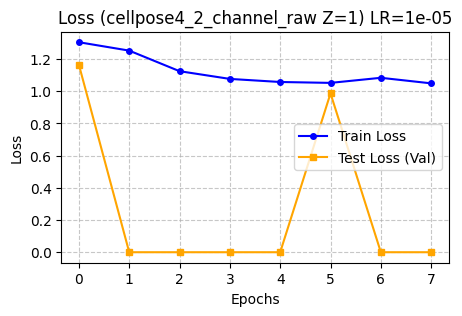


ÉTAPE 2/11 : Apprentissage du plan Z=2 à partir de Z=1
Génération des pseudo-labels pour Z=2...
2026-04-24 14:48:56,193 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 14:48:56,193 [INFO] >>>> using GPU (CUDA)
2026-04-24 14:48:58,775 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z1
2026-04-24 14:48:59,713 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 14:49:30,553 [INFO] 61%|######    | 28/46 [00:30<00:19,  1.10s/it]
2026-04-24 14:49:42,692 [INFO] No cell pixels found.
2026-04-24 14:49:50,585 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.11s/it]
2026-04-24 14:49:50,586 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 14:49:54,156 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.12it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 14:5

100%|██████████| 46/46 [00:04<00:00,  9.68it/s]

2026-04-24 14:50:55,630 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 10.02it/s]

2026-04-24 14:50:56,035 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 740.72it/s]

2026-04-24 14:50:56,102 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 14:50:56,103 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 14:50:56,707 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 14:50:56,708 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 14:50:56,710 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z2
2026-04-24 14:51:31,762 [INFO] 0, train_loss=1.0767, test_loss=0.9435, LR=0.000000, time 35.05s
2026-04-24 14:54:27,300 [INFO] 5, train_loss=0.9929, test_loss=0.8471, LR=0.000006, time 210.59s
2026-04-24 14:55:35,865 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z2
2026-04-24 15:00:46,191 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=2 sauvegardé : models/cellpose4_2_channel_raw_z2


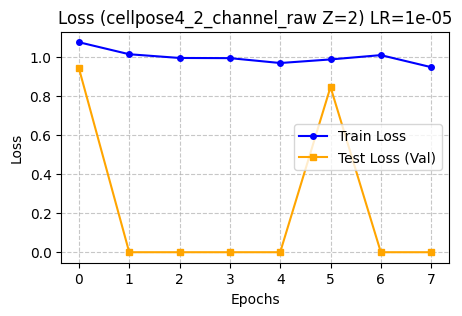


ÉTAPE 3/11 : Apprentissage du plan Z=3 à partir de Z=2
Génération des pseudo-labels pour Z=3...
2026-04-24 15:00:46,650 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 15:00:46,651 [INFO] >>>> using GPU (CUDA)
2026-04-24 15:00:49,250 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z2
2026-04-24 15:00:50,355 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:01:21,023 [INFO] 61%|######    | 28/46 [00:30<00:19,  1.10s/it]
2026-04-24 15:01:33,054 [WARNING] no seeds found in get_masks_torch - no masks found.
2026-04-24 15:01:40,983 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.10s/it]
2026-04-24 15:01:40,984 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:01:43,912 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.37it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les

100%|██████████| 46/46 [00:04<00:00, 10.12it/s]

2026-04-24 15:02:45,501 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 13.13it/s]

2026-04-24 15:02:45,810 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 730.94it/s]

2026-04-24 15:02:45,877 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 15:02:45,878 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 15:02:46,467 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 15:02:46,468 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 15:02:46,470 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z3
2026-04-24 15:03:21,765 [INFO] 0, train_loss=0.9563, test_loss=0.7754, LR=0.000000, time 35.29s
2026-04-24 15:06:17,912 [INFO] 5, train_loss=0.9327, test_loss=0.7087, LR=0.000006, time 211.44s
2026-04-24 15:07:25,178 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z3
2026-04-24 15:12:36,463 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=3 sauvegardé : models/cellpose4_2_channel_raw_z3


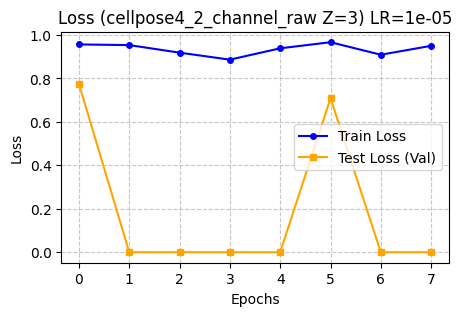


ÉTAPE 4/11 : Apprentissage du plan Z=4 à partir de Z=3
Génération des pseudo-labels pour Z=4...
2026-04-24 15:12:36,938 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 15:12:36,939 [INFO] >>>> using GPU (CUDA)
2026-04-24 15:12:39,302 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z3
2026-04-24 15:12:40,236 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:13:31,131 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.11s/it]
2026-04-24 15:13:31,132 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:13:35,071 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.02it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 15:14:34,346 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 15:14:34,357 [INFO] computing flows for labels


100%|██████████| 46/46 [00:04<00:00, 11.06it/s]

2026-04-24 15:14:38,547 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 12.31it/s]

2026-04-24 15:14:38,878 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 754.30it/s]

2026-04-24 15:14:38,945 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 15:14:38,946 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 15:14:39,529 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 15:14:39,530 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 15:14:39,532 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z4
2026-04-24 15:15:14,615 [INFO] 0, train_loss=0.9217, test_loss=0.6806, LR=0.000000, time 35.08s
2026-04-24 15:18:10,321 [INFO] 5, train_loss=0.8870, test_loss=0.6540, LR=0.000006, time 210.79s
2026-04-24 15:19:20,319 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z4
2026-04-24 15:22:37,863 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=4 sauvegardé : models/cellpose4_2_channel_raw_z4


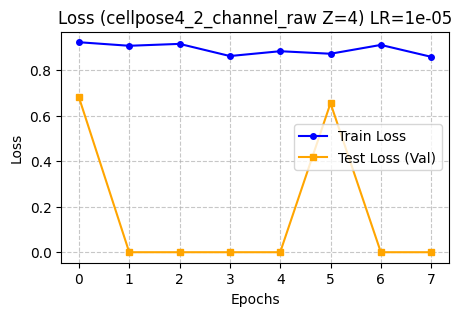


ÉTAPE 5/11 : Apprentissage du plan Z=5 à partir de Z=4
Génération des pseudo-labels pour Z=5...
2026-04-24 15:22:38,337 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 15:22:38,338 [INFO] >>>> using GPU (CUDA)
2026-04-24 15:22:40,807 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z4
2026-04-24 15:22:41,740 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:23:31,943 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.09s/it]
2026-04-24 15:23:31,944 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:23:35,325 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.18it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 15:24:33,302 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 15:24:33,312 [INFO] computing flows for labels


100%|██████████| 46/46 [00:03<00:00, 12.57it/s]

2026-04-24 15:24:36,999 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 15.52it/s]

2026-04-24 15:24:37,262 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 774.29it/s]

2026-04-24 15:24:37,329 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 15:24:37,329 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 15:24:37,912 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 15:24:37,913 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 15:24:37,914 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z5
2026-04-24 15:25:13,120 [INFO] 0, train_loss=0.9297, test_loss=0.7604, LR=0.000000, time 35.21s
2026-04-24 15:28:08,791 [INFO] 5, train_loss=0.8875, test_loss=0.7535, LR=0.000006, time 210.88s
2026-04-24 15:29:14,862 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z5
2026-04-24 15:36:40,358 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=5 sauvegardé : models/cellpose4_2_channel_raw_z5


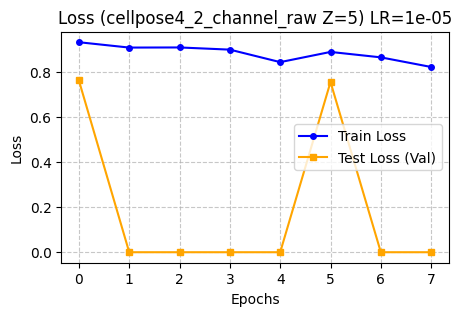


ÉTAPE 6/11 : Apprentissage du plan Z=6 à partir de Z=5
Génération des pseudo-labels pour Z=6...
2026-04-24 15:36:40,832 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 15:36:40,832 [INFO] >>>> using GPU (CUDA)
2026-04-24 15:36:42,934 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z5
2026-04-24 15:36:43,802 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:37:33,798 [INFO] 100%|##########| 46/46 [00:49<00:00,  1.09s/it]
2026-04-24 15:37:33,799 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:37:37,592 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.05it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 15:38:34,274 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 15:38:34,284 [INFO] computing flows for labels


100%|██████████| 46/46 [00:02<00:00, 16.10it/s]

2026-04-24 15:38:37,168 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 15.37it/s]

2026-04-24 15:38:37,434 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 758.94it/s]

2026-04-24 15:38:37,502 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 15:38:38,070 [INFO] >>> n_epochs=8, n_train=46, n_test=4
2026-04-24 15:38:38,071 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 15:38:38,073 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z6
2026-04-24 15:39:13,845 [INFO] 0, train_loss=0.7646, test_loss=0.7497, LR=0.000000, time 35.77s
2026-04-24 15:42:13,181 [INFO] 5, train_loss=0.7644, test_loss=0.7128, LR=0.000006, time 215.11s
2026-04-24 15:43:19,714 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z6
2026-04-24 15:49:06,861 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=6 sauvegardé : models/cellpose4_2_channel_raw_z6


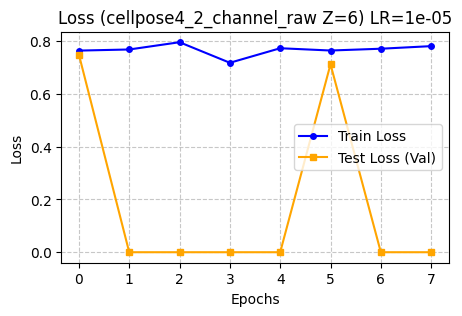


ÉTAPE 7/11 : Apprentissage du plan Z=7 à partir de Z=6
Génération des pseudo-labels pour Z=7...
2026-04-24 15:49:07,591 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 15:49:07,591 [INFO] >>>> using GPU (CUDA)
2026-04-24 15:49:09,868 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z6
2026-04-24 15:49:10,739 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:50:00,876 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.09s/it]
2026-04-24 15:50:00,877 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 15:50:04,266 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.18it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 15:51:00,373 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 15:51:00,383 [INFO] computing flows for labels


100%|██████████| 46/46 [00:02<00:00, 18.94it/s]

2026-04-24 15:51:02,839 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 16.82it/s]

2026-04-24 15:51:03,082 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 762.05it/s]

2026-04-24 15:51:03,149 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 15:51:03,721 [INFO] >>> n_epochs=8, n_train=46, n_test=4
2026-04-24 15:51:03,722 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 15:51:03,725 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z7
2026-04-24 15:51:39,508 [INFO] 0, train_loss=0.6334, test_loss=0.5982, LR=0.000000, time 35.78s
2026-04-24 15:54:39,180 [INFO] 5, train_loss=0.6019, test_loss=0.5533, LR=0.000006, time 215.46s
2026-04-24 15:55:45,469 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z7
2026-04-24 16:01:18,565 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=7 sauvegardé : models/cellpose4_2_channel_raw_z7


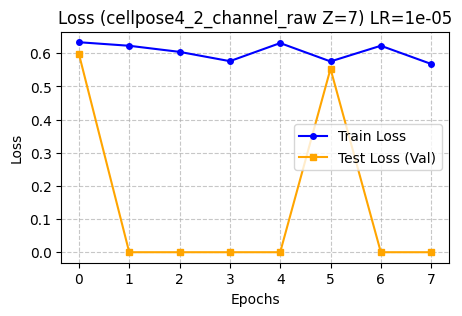


ÉTAPE 8/11 : Apprentissage du plan Z=8 à partir de Z=7
Génération des pseudo-labels pour Z=8...
2026-04-24 16:01:19,040 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 16:01:19,041 [INFO] >>>> using GPU (CUDA)
2026-04-24 16:01:21,322 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z7
2026-04-24 16:01:22,224 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:02:11,898 [INFO] 100%|##########| 46/46 [00:49<00:00,  1.08s/it]
2026-04-24 16:02:11,899 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:02:15,269 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.19it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 16:03:11,327 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 16:03:11,337 [INFO] computing flows for labels


100%|██████████| 46/46 [00:02<00:00, 20.42it/s]

2026-04-24 16:03:13,617 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 20.80it/s]

2026-04-24 16:03:13,815 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 731.58it/s]

2026-04-24 16:03:13,883 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 16:03:14,448 [INFO] >>> n_epochs=8, n_train=46, n_test=4
2026-04-24 16:03:14,449 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 16:03:14,451 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z8
2026-04-24 16:03:50,290 [INFO] 0, train_loss=0.5465, test_loss=0.4666, LR=0.000000, time 35.84s
2026-04-24 16:06:49,746 [INFO] 5, train_loss=0.5437, test_loss=0.3702, LR=0.000006, time 215.30s
2026-04-24 16:07:56,233 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z8
2026-04-24 16:12:08,610 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=8 sauvegardé : models/cellpose4_2_channel_raw_z8


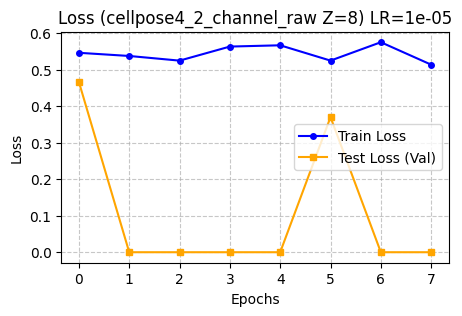


ÉTAPE 9/11 : Apprentissage du plan Z=9 à partir de Z=8
Génération des pseudo-labels pour Z=9...
2026-04-24 16:12:09,070 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 16:12:09,071 [INFO] >>>> using GPU (CUDA)
2026-04-24 16:12:11,286 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z8
2026-04-24 16:12:12,152 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:13:02,656 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.10s/it]
2026-04-24 16:13:02,657 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:13:05,587 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.37it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 16:14:00,834 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 16:14:00,843 [INFO] computing flows for labels


100%|██████████| 46/46 [00:02<00:00, 21.28it/s]

2026-04-24 16:14:03,032 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 21.92it/s]

2026-04-24 16:14:03,219 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 766.43it/s]

2026-04-24 16:14:03,287 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 16:14:03,852 [INFO] >>> n_epochs=8, n_train=46, n_test=4
2026-04-24 16:14:03,853 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 16:14:03,855 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z9
2026-04-24 16:14:40,592 [INFO] 0, train_loss=0.5127, test_loss=0.2865, LR=0.000000, time 36.74s
2026-04-24 16:17:41,319 [INFO] 5, train_loss=0.4685, test_loss=0.2664, LR=0.000006, time 217.46s
2026-04-24 16:18:47,045 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z9
2026-04-24 16:23:20,052 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=9 sauvegardé : models/cellpose4_2_channel_raw_z9


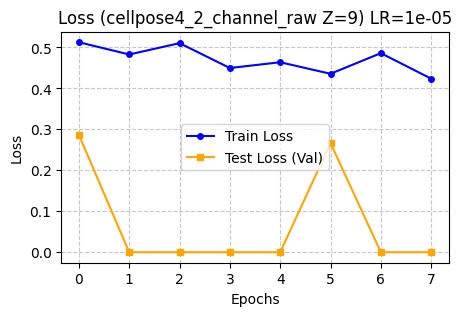


ÉTAPE 10/11 : Apprentissage du plan Z=10 à partir de Z=9
Génération des pseudo-labels pour Z=10...
2026-04-24 16:23:20,496 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 16:23:20,496 [INFO] >>>> using GPU (CUDA)
2026-04-24 16:23:22,494 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z9
2026-04-24 16:23:23,154 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:24:13,370 [INFO] 100%|##########| 46/46 [00:50<00:00,  1.09s/it]
2026-04-24 16:24:13,371 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:24:17,181 [INFO] 100%|##########| 4/4 [00:03<00:00,  1.05it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 16:25:12,651 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 16:25:12,661 [INFO] computing flows for label

100%|██████████| 46/46 [00:02<00:00, 22.21it/s]

2026-04-24 16:25:14,758 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 21.01it/s]

2026-04-24 16:25:14,954 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 762.60it/s]

2026-04-24 16:25:15,022 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 16:25:15,598 [INFO] >>> n_epochs=8, n_train=46, n_test=4
2026-04-24 16:25:15,599 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 16:25:15,602 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z10
2026-04-24 16:25:52,353 [INFO] 0, train_loss=0.4338, test_loss=0.4201, LR=0.000000, time 36.75s
2026-04-24 16:28:53,065 [INFO] 5, train_loss=0.4025, test_loss=0.3568, LR=0.000006, time 217.46s
2026-04-24 16:29:55,867 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z10
2026-04-24 16:34:47,393 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=10 sauvegardé : models/cellpose4_2_channel_raw_z10


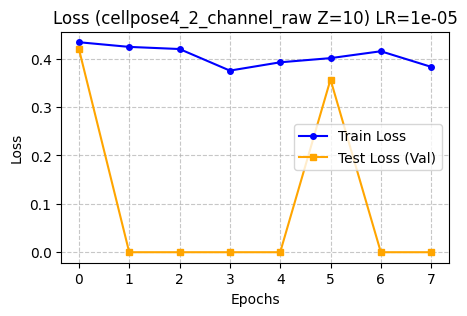


ÉTAPE 11/11 : Apprentissage du plan Z=11 à partir de Z=10
Génération des pseudo-labels pour Z=11...
2026-04-24 16:34:47,832 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 16:34:47,833 [INFO] >>>> using GPU (CUDA)
2026-04-24 16:34:49,799 [INFO] >>>> loading model models/cellpose4_2_channel_raw_z10
2026-04-24 16:34:50,403 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:35:17,509 [INFO] 100%|##########| 46/46 [00:27<00:00,  1.70it/s]
2026-04-24 16:35:17,510 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-24 16:35:19,852 [INFO] 100%|##########| 4/4 [00:02<00:00,  1.71it/s]
Sauvegarde des masques et génération des graphiques...
Affinage du modèle sur les pseudo-labels...
2026-04-24 16:36:14,214 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-24 16:36:14,224 [INFO] computing flows for lab

100%|██████████| 46/46 [00:01<00:00, 27.72it/s]

2026-04-24 16:36:15,909 [INFO] computing flows for labels



100%|██████████| 4/4 [00:00<00:00, 27.06it/s]

2026-04-24 16:36:16,062 [INFO] >>> computing diameters



100%|██████████| 4/4 [00:00<00:00, 745.75it/s]

2026-04-24 16:36:16,130 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-24 16:36:16,131 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-24 16:36:16,685 [INFO] >>> n_epochs=8, n_train=45, n_test=4
2026-04-24 16:36:16,686 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-24 16:36:16,688 [INFO] >>> saving model to models/cellpose4_2_channel_raw_z11
2026-04-24 16:36:34,224 [INFO] 0, train_loss=0.2799, test_loss=0.2841, LR=0.000000, time 17.54s
2026-04-24 16:38:00,591 [INFO] 5, train_loss=0.2562, test_loss=0.2184, LR=0.000006, time 103.90s
2026-04-24 16:38:34,832 [INFO] saving network parameters to models/cellpose4_2_channel_raw_z11
2026-04-24 16:41:05,410 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Z=11 sauvegardé : models/cellpose4_2_channel_raw_z11


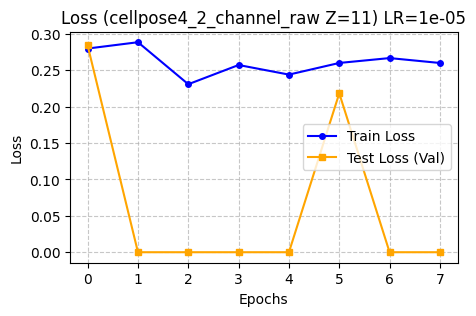


Entraînement séquentiel 3D terminé avec succès.


HTTPResponseError: HTTP error: 504

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io

label = "cellpose4_2_channel_raw"
target = "Cell"                                    
initial_model_path = "./models/cyto4_40_raw.pth" 
total_steps = 12

# Paramètres d'inférence et d'entraînement
eval_params = {
    "channels": [1, 2],
    "diameter": None,
    "flow_threshold": 0.5,
    "cellprob_threshold": 0.0
}

train_params = {
    "n_epochs": 8,
    "learning_rate": 1e-5,
    "weight_decay": 0.0001,
    "save_path": '.'
}

io.logger_setup()
current_model_path = initial_model_path

base_output = os.path.abspath("./results/sequential_training_cell")
os.makedirs(base_output, exist_ok=True)

for i in range(total_steps - 1):
    z_current = i
    z_next = i + 1

    print(f"\n{'='*6}")
    print(f"ÉTAPE {z_next}/{total_steps-1} : Apprentissage du plan Z={z_next} à partir de Z={z_current}")
    print(f"{'='*6}")

    # --- 1. Création des dossiers (ATTENTION: z_next doit être défini avant) ---
    model_root = os.path.join(base_output, f"step_{z_next}")
    output_dir_masks = os.path.join(model_root, "masks")
    output_dir_viz = os.path.join(model_root, "viz")
    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    # --- 2. Chargement des images cibles (Z+1) ---
    X_train_next = visualizer.load_channel_z_relative(ids_train, df_meta=df_meta, step=z_next, total_steps=total_steps, mode = "raw")
    X_val_next = visualizer.load_channel_z_relative(ids_val, df_meta=df_meta, step=z_next, total_steps=total_steps, mode = "raw")

    # --- 3. Évaluation Vectorisée (GPU à 100%) ---
    print(f"Génération des pseudo-labels pour Z={z_next}...")
    model_eval = models.CellposeModel(gpu=True, pretrained_model=current_model_path)

    # Cellpose traite toute la liste X d'un seul coup et recrache une liste Y
    Y_train_pseudo, _, _= model_eval.eval(X_train_next, **eval_params)
    Y_val_pseudo, _, _ = model_eval.eval(X_val_next, **eval_params)

    # --- 4. Boucle de Sauvegarde et Plotting (Train & Val) ---
    print("Sauvegarde des masques et génération des graphiques...")
    
    # On fusionne Train et Val pour traiter toutes les sauvegardes dans la même boucle logique
    all_ids = ids_train + ids_val
    all_X = X_train_next + X_val_next
    all_Y = Y_train_pseudo + Y_val_pseudo

    # zip() permet de lire l'ID, l'image et le masque en même temps !
    for img_id, img_array, mask_pred in zip(all_ids, all_X, all_Y):
        
        # Sauvegarde du masque
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_{target}_pred.bmp")
        cv2.imwrite(save_path_mask, mask_pred.astype(np.uint16)) 

        # Visualisation directe (sans repasser par load_data)
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        ax1, ax2 = axes.flatten()
        
        ax1.imshow(img_array[0], cmap='gray')
        ax1.set_title(f"A. Image Entrée (Z-relatif={z_next})")
        ax1.axis('off')

        # Si votre plot_overlay prend un array NumPy en argument (mask_pred) :
        visualizer.plot_overlay(i=img_id, mask_pred=mask_pred, ax=ax2, show=False, annotation=False, prediction=True, image= img_array[0])
        ax2.set_title(f"B. Prédiction Cellpose - {target}")
        
        titre_rapport = f"Pseudo-label : {img_id} ({label})"
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        fig.subplots_adjust(top=0.90)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    
    # --- 5. Fine-Tuning du Modèle ---
    print(f"Affinage du modèle sur les pseudo-labels...")
    model_name = f"{label}_z{z_next}"

    new_model_path, t_loss, v_loss = train.train_seg(
        model_eval.net,
        train_data=X_train_next,
        train_labels=Y_train_pseudo,
        test_data=X_val_next,
        test_labels=Y_val_pseudo,
        model_name=model_name,
        **train_params 
    )

    print(f"Modèle Z={z_next} sauvegardé : {new_model_path}")

    # --- 6. Affichage de la Loss ---
    title = f"Loss ({label} Z={z_next}) LR={train_params['learning_rate']}"
    visualizer.plot_loss(t_loss, v_loss, title=title, show=True)

    # Mise à jour du poids pour le palier suivant
    current_model_path = new_model_path

print("\nEntraînement séquentiel 3D terminé avec succès.")
chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cell_stack"
oc.download_path(base_output, chemin_export_global)


In [6]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_cell_stack.pth',
    current_model_path, timeout=600                                  
)

HTTPResponseError: HTTP error: 504